In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data/processed/epo_english_v1")
REPORTS_DIR = Path("../reports/eda/epo_english_v1")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="viridis")

In [2]:
patents = pd.read_parquet(DATA_DIR / "patents.parquet")

patent_texts = pd.read_parquet(
    DATA_DIR / "patent_texts.parquet",
)

classifications = pd.read_parquet(
    DATA_DIR / "classifications.parquet",
    columns=[
        "publication_id",
        "classification_system",
        "classification_code",
    ],
)

In [3]:
summary = pd.Series(
    {
        "patents": len(patents),
        "families": patents["family_id"].nunique(),
        "english_texts": len(patent_texts),
        "IPCR labels": (classifications["classification_system"] == "IPCR").sum(),
        "CPCI labels": (classifications["classification_system"] == "CPCI").sum(),
    }
)

summary

patents           151668
families          147401
english_texts     151668
IPCR labels       464295
CPCI labels      1244699
dtype: int64

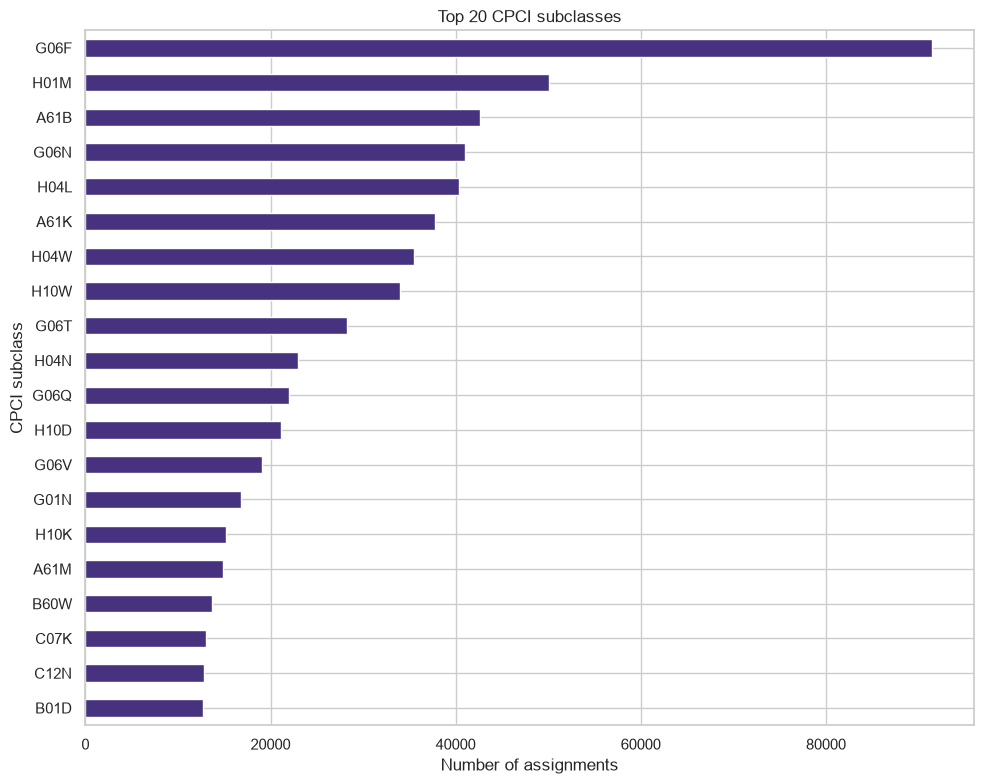

In [4]:
cpci = classifications[classifications["classification_system"] == "CPCI"].copy()

top_cpci = cpci["classification_code"].str[:4].value_counts().head(20).sort_values()

plt.figure(figsize=(10, 8))
top_cpci.plot(kind="barh")
plt.title("Top 20 CPCI subclasses")
plt.xlabel("Number of assignments")
plt.ylabel("CPCI subclass")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "top_cpci_subclasses.png", dpi=160)
plt.show()

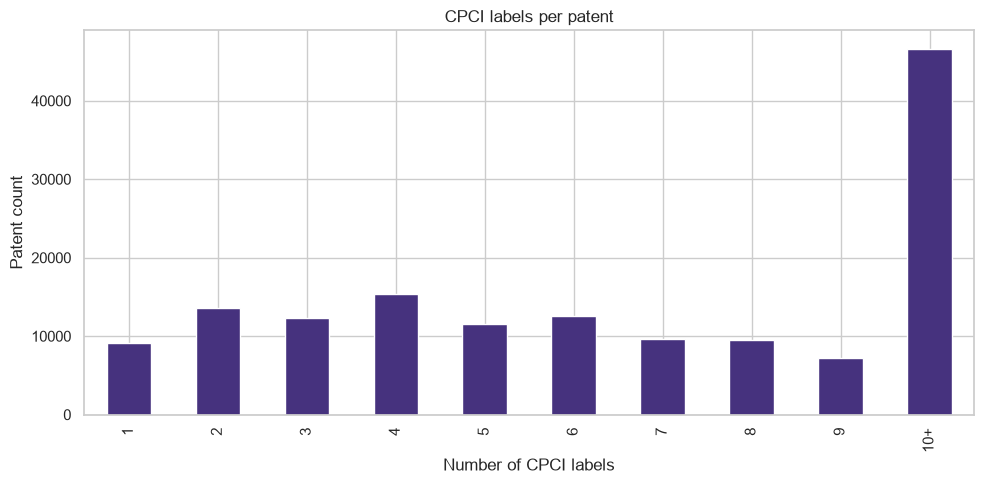

In [6]:
labels_per_patent = cpci.groupby("publication_id").size()

binned_labels = labels_per_patent.clip(upper=10).astype(str).replace({"10": "10+"})

label_counts = binned_labels.value_counts().reindex(
    [str(number) for number in range(1, 10)] + ["10+"],
    fill_value=0,
)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("CPCI labels per patent")
plt.xlabel("Number of CPCI labels")
plt.ylabel("Patent count")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "cpci_labels_per_patent.png", dpi=160)
plt.show()